# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [8]:
# importing Libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Visualize Dataset

In [9]:
# Check whether it has missing data
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

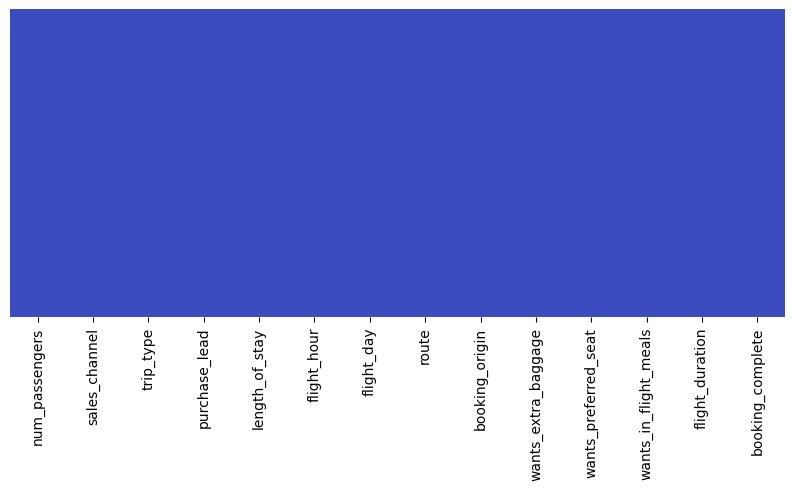

In [10]:
# we have checked about missing data and we don't have any missing data but we will check it with visualization also
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='coolwarm')
plt.savefig("plot1.png", dpi=300)
plt.show()

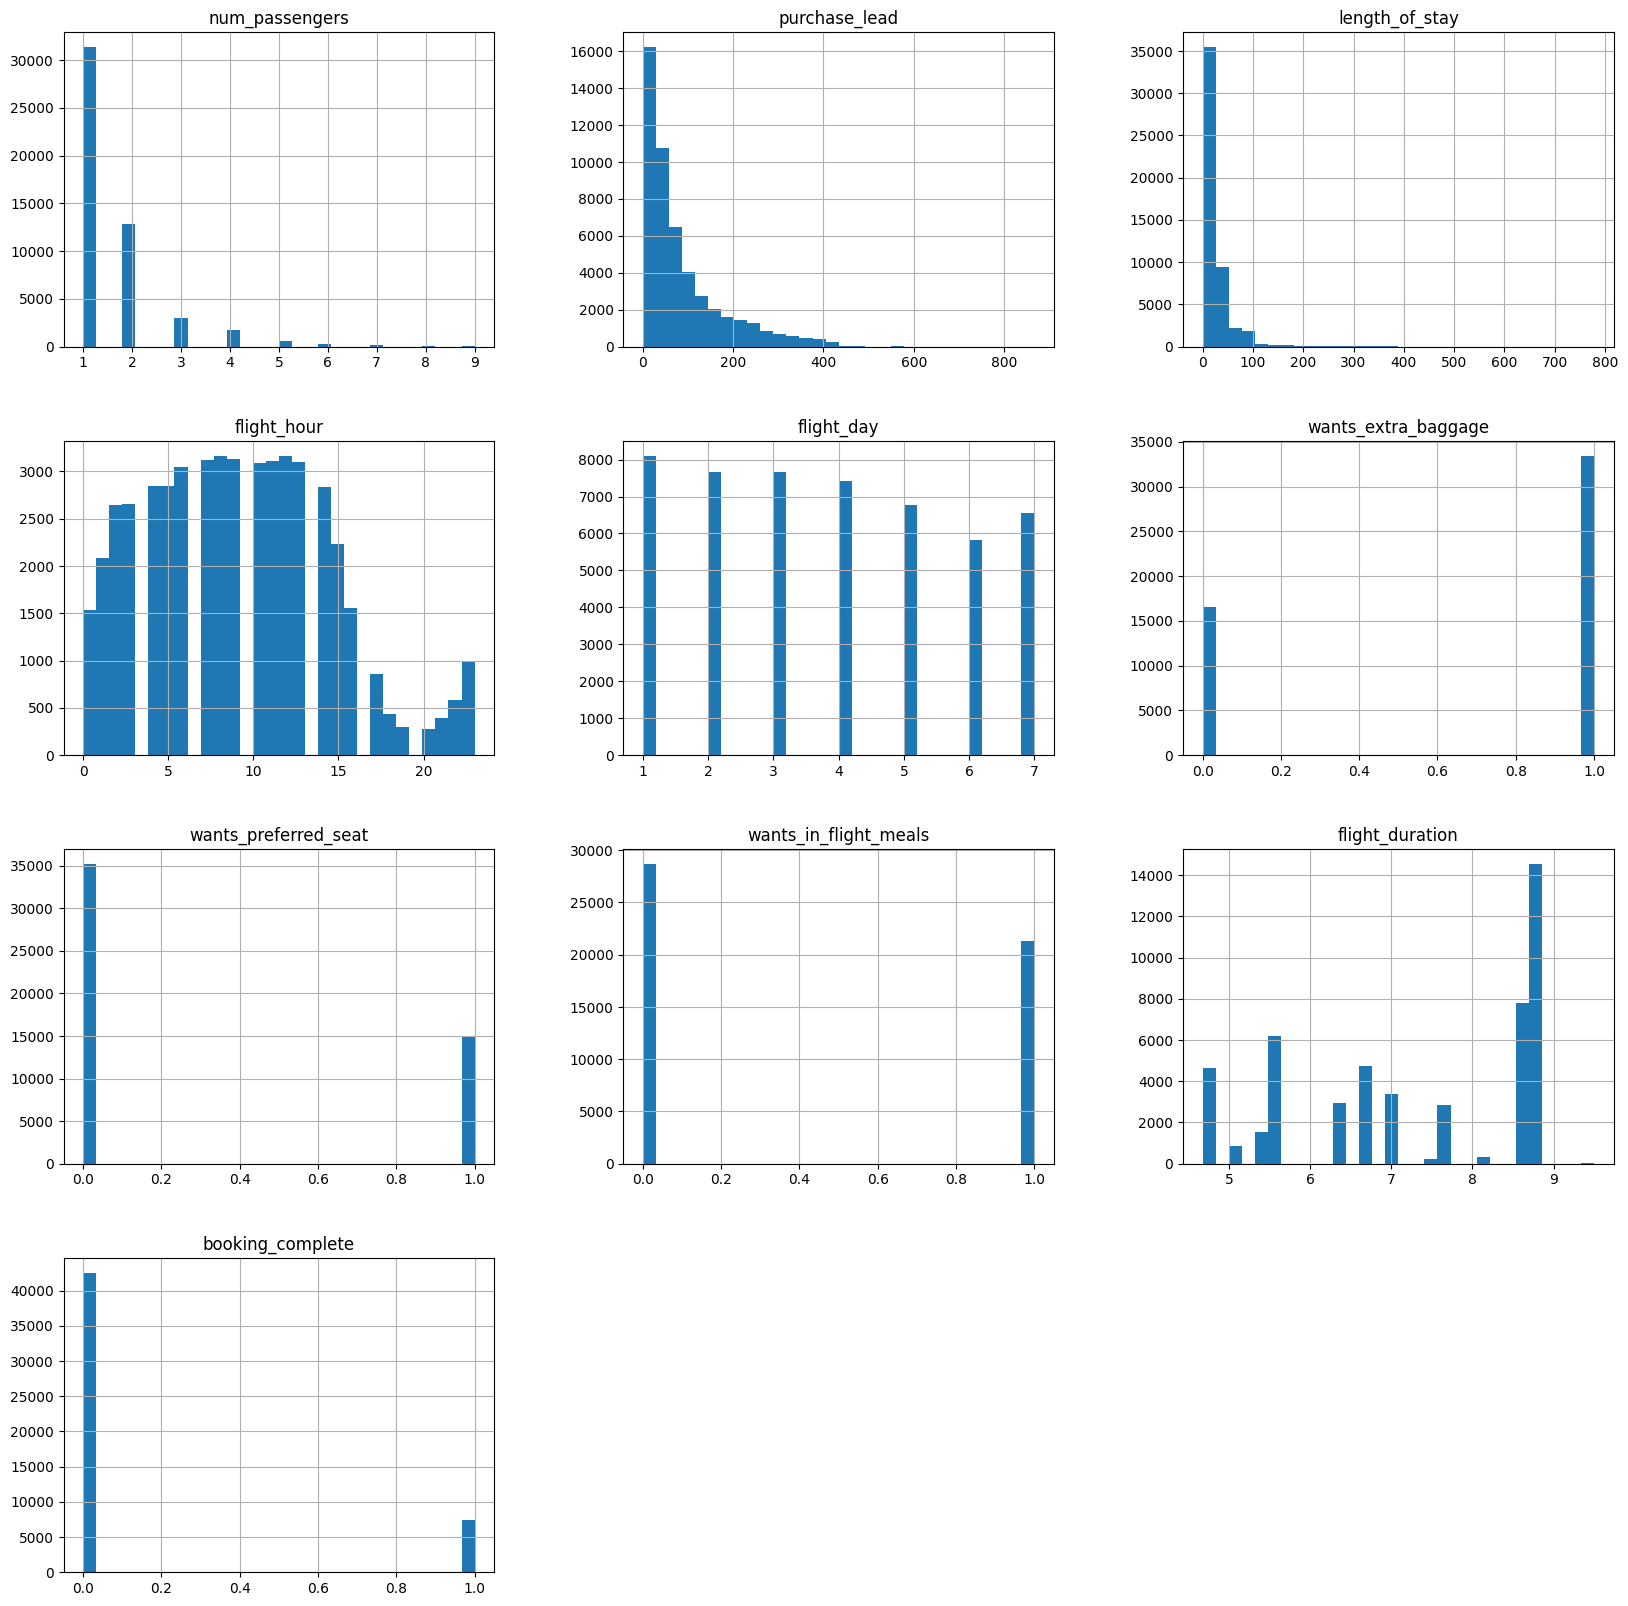

In [11]:
# we  are using a histogram to check all data of a dataset for more info visuall
df.hist(bins=30,figsize=(20,20))
plt.savefig("plot2.png", dpi=300)
plt.show()

In [12]:
# Analize completed booking and not completed booking
booking_complete = df[df['booking_complete'] == 0]
booking__not_complete = df[df['booking_complete'] == 1]

In [13]:
# Percentage of Booking complete and not complete
print(f'Total = {len(df)}')
print(f'Number of people who completed Booking = {len(booking_complete)}')
print(f'Percent of people who completed Booking = {len(booking_complete)/len(df)*100}%')
print(f'Number of people who not completed Booking = {len(booking__not_complete)}')
print(f'Percent of people who not completed Booking = {len(booking__not_complete)/len(df)*100}%')

Total = 50000
Number of people who completed Booking = 42522
Percent of people who completed Booking = 85.044%
Number of people who not completed Booking = 7478
Percent of people who not completed Booking = 14.956%


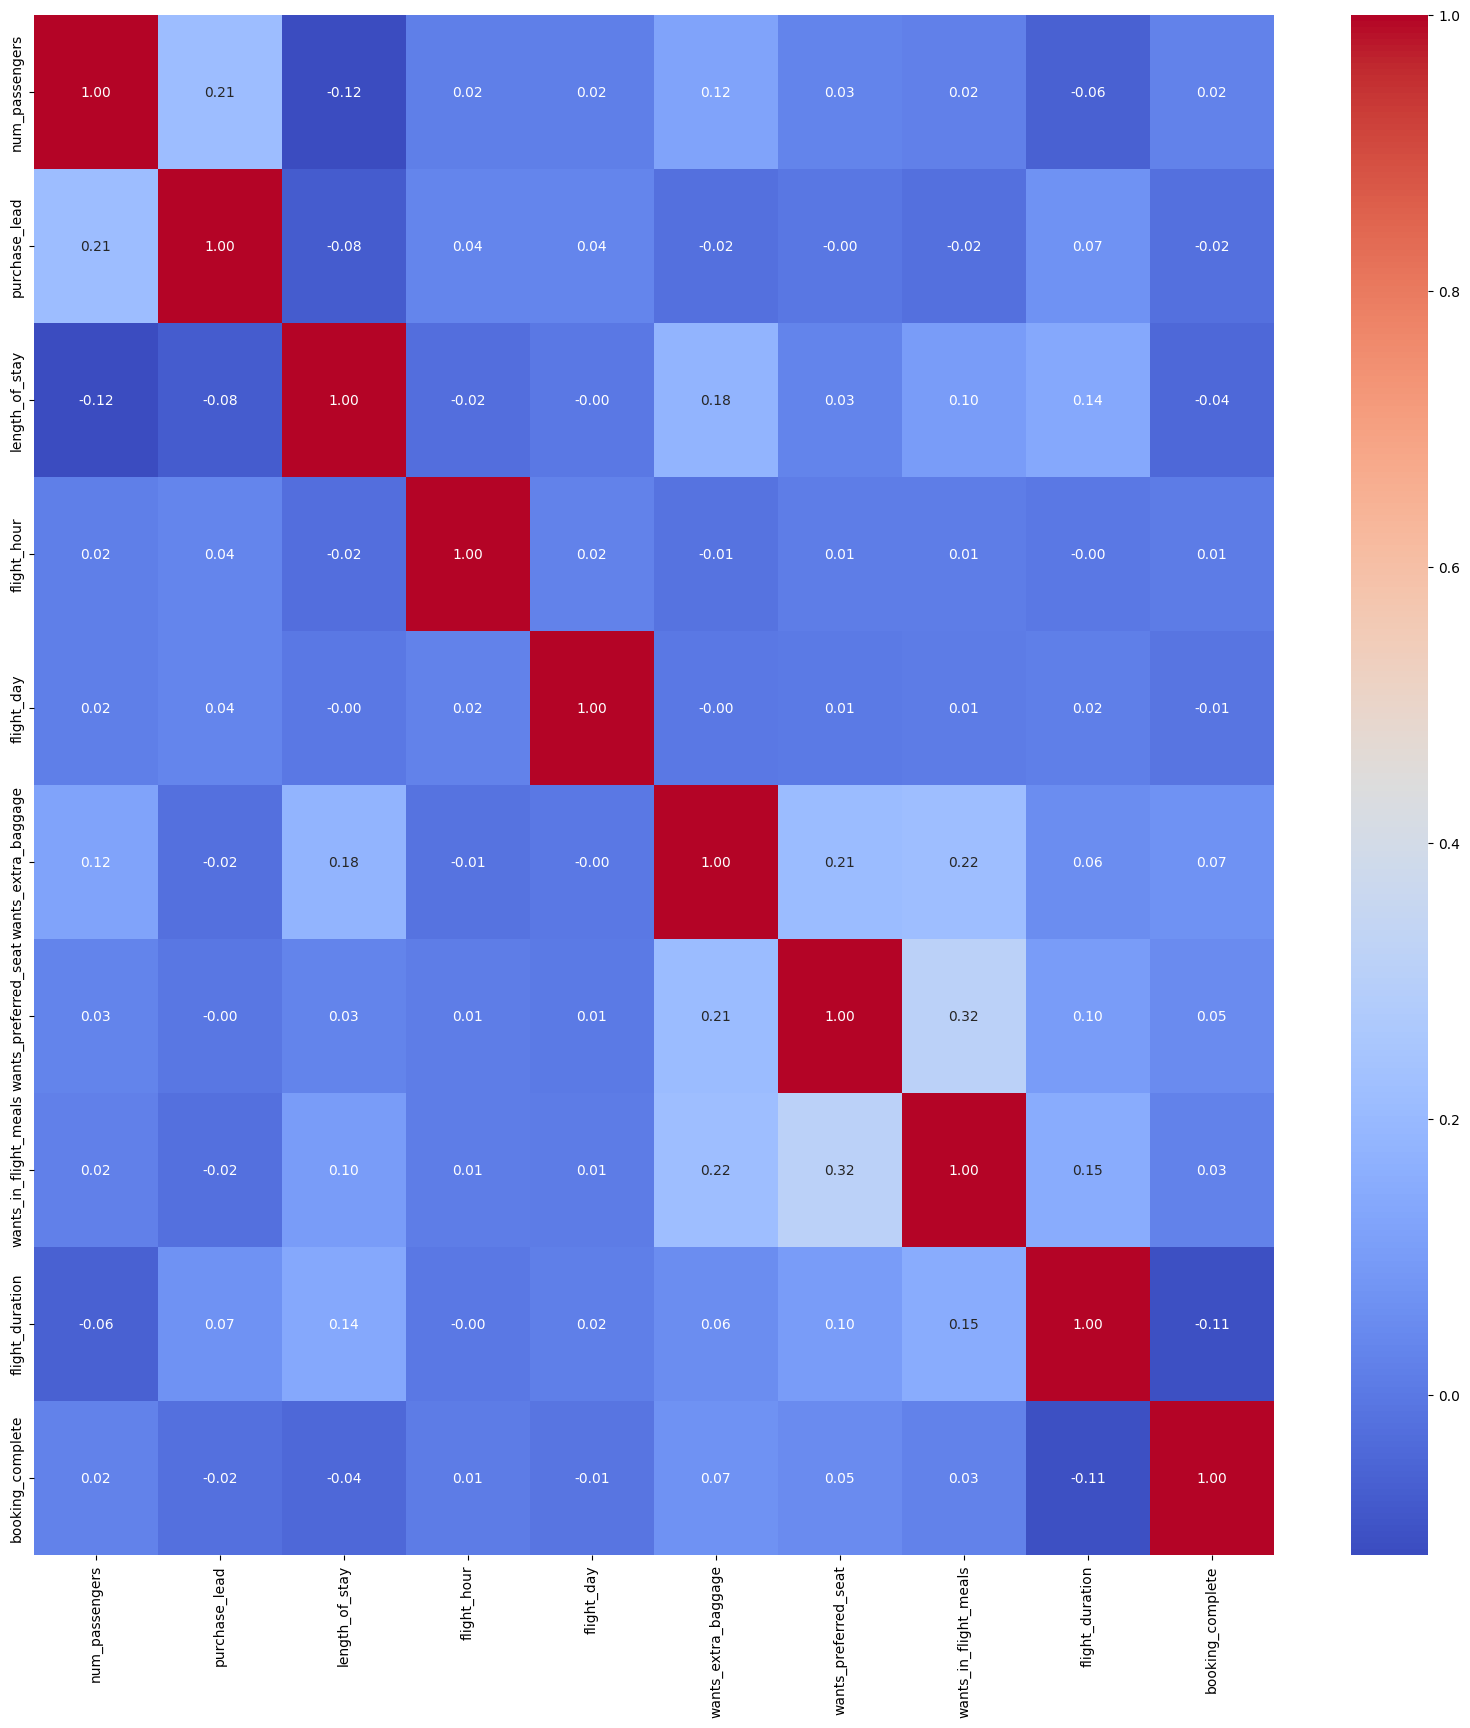

In [14]:
correlations = df.select_dtypes(include='number').corr()
plt.figure(figsize= (20,20))
sns.heatmap(correlations, annot = True, cmap='coolwarm', fmt='.2f')  
plt.savefig("plot3.png", dpi=300)
plt.show()

### Mutual Information

In [15]:
X= df.drop('booking_complete',axis=1)
y= df.booking_complete         

#changing object dtype to int dtype
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

In [16]:
X.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
0,2,0,0,262,19,7,6,0,0,1,0,0,5.52
1,1,0,0,112,20,3,6,0,0,0,0,0,5.52
2,2,0,0,243,22,17,3,0,1,1,1,0,5.52
3,1,0,0,96,31,4,6,0,0,0,0,1,5.52
4,2,0,0,68,22,15,3,0,1,1,0,1,5.52


In [17]:
X.dtypes

num_passengers             int64
sales_channel              int64
trip_type                  int64
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                 int64
route                      int64
booking_origin             int64
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
dtype: object

In [18]:
from sklearn.feature_selection import mutual_info_classif

mi_score = mutual_info_classif(X, y)
mi_score = pd.Series(mi_score, name="MI Score", index=X.columns)
mi_score = mi_score.sort_values(ascending=False)

mi_score

route                    0.052935
booking_origin           0.050592
flight_duration          0.016795
wants_extra_baggage      0.010676
length_of_stay           0.007616
wants_in_flight_meals    0.006803
num_passengers           0.004031
wants_preferred_seat     0.003051
trip_type                0.002880
flight_hour              0.002683
purchase_lead            0.002152
sales_channel            0.001777
flight_day               0.000628
Name: MI Score, dtype: float64

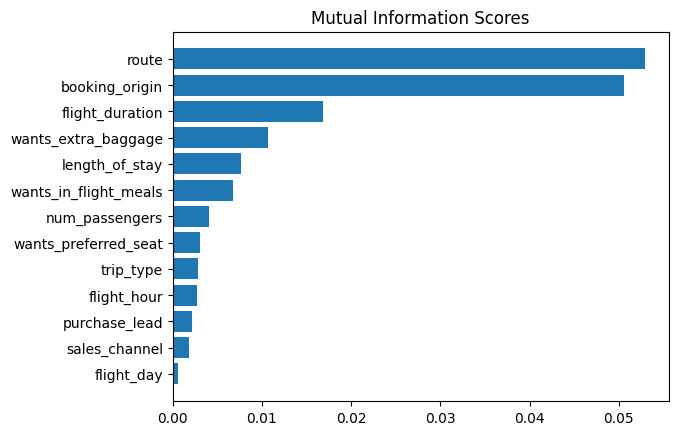

<Figure size 800x500 with 0 Axes>

In [19]:
def plot_mi_score(score):
    score = score.sort_values(ascending=True)
    width = np.arange(len(score))
    ticks = list(score.index)
    plt.barh(width, score)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
    
    a= plt.figure(dpi=100, figsize=(8, 5))
    plt.savefig("plot4.png")
    plt.show()
plot_mi_score(mi_score)   


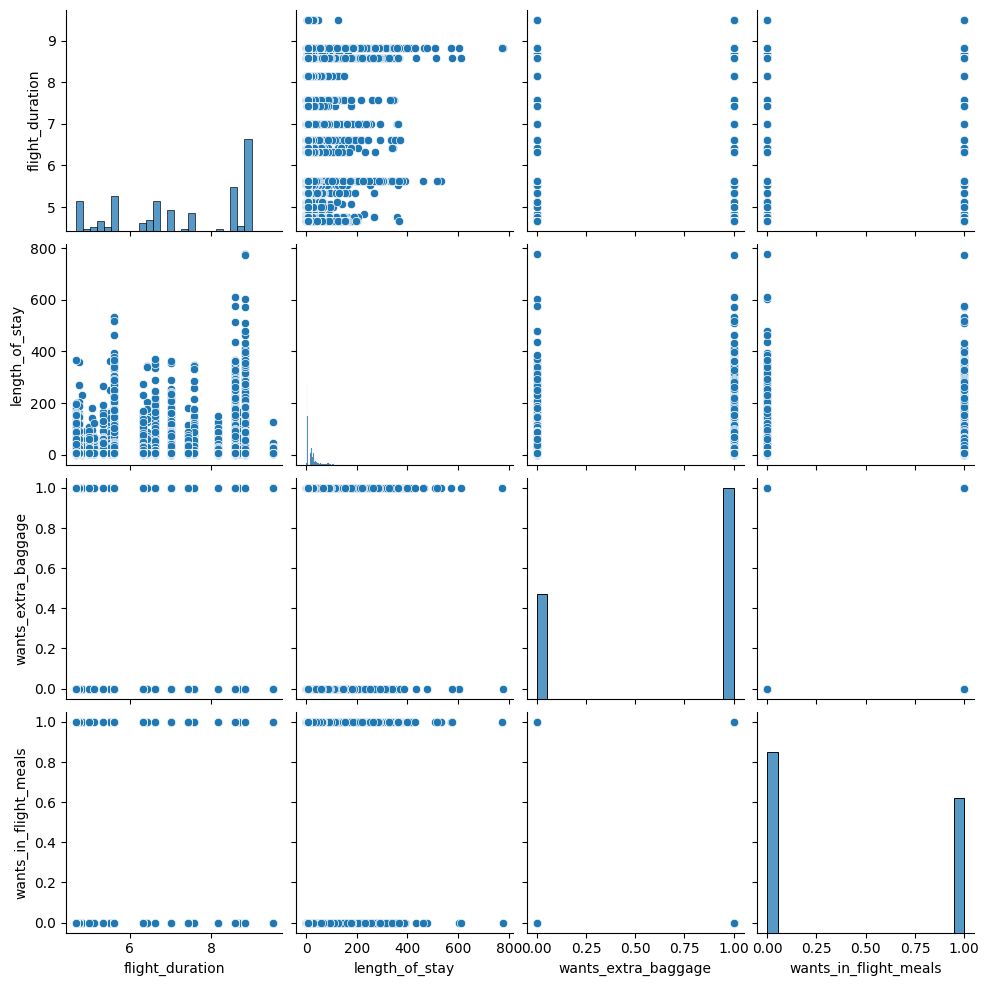

In [20]:
sns.pairplot(df[['route', 'booking_origin', 'flight_duration', 'length_of_stay', 'wants_extra_baggage','wants_in_flight_meals']])
plt.savefig("plot5.png")
plt.show()

## Preprocessing Dataset

In [21]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0


In [22]:
df.shape

(50000, 14)

In [23]:
# All categorical data
X_cat = df[['sales_channel','trip_type','flight_day','route','booking_origin']]
cat_name = X_cat.columns.to_list()
X_cat

,sales_channel,trip_type,flight_day,route,booking_origin
0,Internet,RoundTrip,6,AKLDEL,New Zealand
1,Internet,RoundTrip,6,AKLDEL,New Zealand
2,Internet,RoundTrip,3,AKLDEL,India
3,Internet,RoundTrip,6,AKLDEL,New Zealand
4,Internet,RoundTrip,3,AKLDEL,India
...,...,...,...,...,...
49995,Internet,RoundTrip,6,PERPNH,Australia
49996,Internet,RoundTrip,7,PERPNH,Australia
49997,Internet,RoundTrip,6,PERPNH,Australia
49998,Internet,RoundTrip,1,PERPNH,Australia


In [24]:
# Changing categorical data into number
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder()
X_cat = onehotencoder.fit_transform(X_cat).toarray()
X_cat.shape

(50000, 915)

In [25]:
# Converting to dataframe
X_cat = pd.DataFrame(X_cat, columns=onehotencoder.get_feature_names_out(cat_name))
X_cat

,sales_channel_Internet,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip,flight_day_1,flight_day_2,flight_day_3,flight_day_4,flight_day_5,...,booking_origin_Timor-Leste,booking_origin_Tonga,booking_origin_Tunisia,booking_origin_Turkey,booking_origin_Ukraine,booking_origin_United Arab Emirates,booking_origin_United Kingdom,booking_origin_United States,booking_origin_Vanuatu,booking_origin_Vietnam
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49996,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49998,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# note that we dropped the target 'booking_complete'
X_num = df[['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration']]

In [27]:
# Combining both data num and cat into a single dataframe
X_com = pd.concat([X_cat,X_num],axis=1)
X_com.columns = X_com.columns.astype(str)
X_com

,sales_channel_Internet,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip,flight_day_1,flight_day_2,flight_day_3,flight_day_4,flight_day_5,...,booking_origin_Vanuatu,booking_origin_Vietnam,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2,262,19,7,1,0,0,5.52
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,112,20,3,0,0,0,5.52
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,2,243,22,17,1,1,0,5.52
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,96,31,4,0,0,1,5.52
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,2,68,22,15,1,0,1,5.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2,27,6,9,1,0,1,5.62
49996,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,111,6,4,0,0,0,5.62
49997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,24,6,22,0,0,1,5.62
49998,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,15,6,11,1,0,1,5.62


In [28]:
# Scaling the data using MimMax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_com)
X_scaled

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.17598344],
       [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.17598344],
       [1.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.17598344],
       ...,
       [1.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.19668737],
       [1.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.19668737],
       [1.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.19668737]], shape=(50000, 923))

In [29]:
X_com_name = X_com.columns.to_list()
X_scaler_name = scaler.get_feature_names_out(X_com_name)

In [30]:
y = df['booking_complete']
y.value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

## Training and Testing Dataset

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.25, random_state=42, stratify=y)

In [32]:
X_train.shape ,X_test.shape

((37500, 923), (12500, 923))

### Model Training and Prediction

##### LogisticRegression 

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

In [34]:
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
# Making Prediction 
y_pred = model_lr.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(12500,))

In [36]:
# Accuracy and ROC_AUC score
print(f'Accuracy {100 * accuracy_score(y_pred, y_test):.2f} %')
print(f'AUC score {roc_auc_score(y_pred, y_test):.2f} %')

Accuracy 84.88 %
AUC score 0.66 %


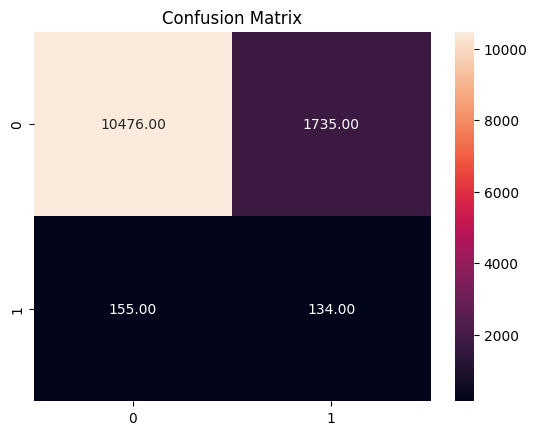

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
# Confusion matrix
cm = confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True, fmt='.2f')
plt.title('Confusion Matrix')
plt.savefig("plot6.png")
plt.show()

In [38]:
# Classification report
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92     12211
           1       0.07      0.46      0.12       289

    accuracy                           0.85     12500
   macro avg       0.53      0.66      0.52     12500
weighted avg       0.96      0.85      0.90     12500



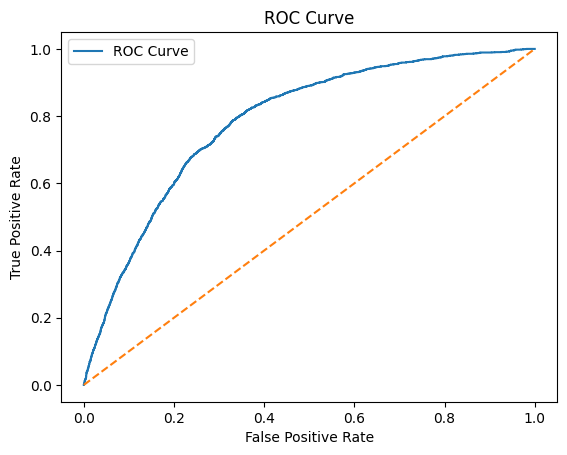

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities
y_prob = model_lr.predict_proba(X_test)[:,1]

# compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plot ROC
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("plot10.png")
plt.show()

##### RandomForestClassifier

In [40]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
# Making prediction
y_pred_forest = model_rf.predict(X_test)

In [42]:
# Accuracy and ROC_AUC score
print(f'Accuracy {100 * accuracy_score(y_pred_forest, y_test):.2f} %')
print(f'AUC score {roc_auc_score(y_pred_forest, y_test):.2f} %')

Accuracy 85.21 %
AUC score 0.69 %


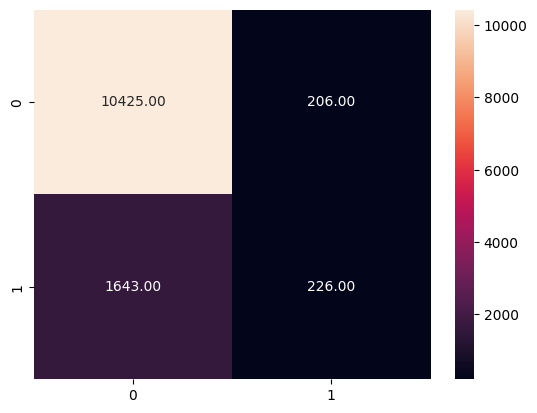

In [43]:
# Testing Set Performance
cm = confusion_matrix(y_test,y_pred_forest)
sns.heatmap(cm,annot=True, fmt='.2f')
plt.savefig("plot7.png")
plt.show()

In [44]:
print(classification_report(y_pred_forest,y_test))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92     12068
           1       0.12      0.52      0.20       432

    accuracy                           0.85     12500
   macro avg       0.55      0.69      0.56     12500
weighted avg       0.95      0.85      0.89     12500



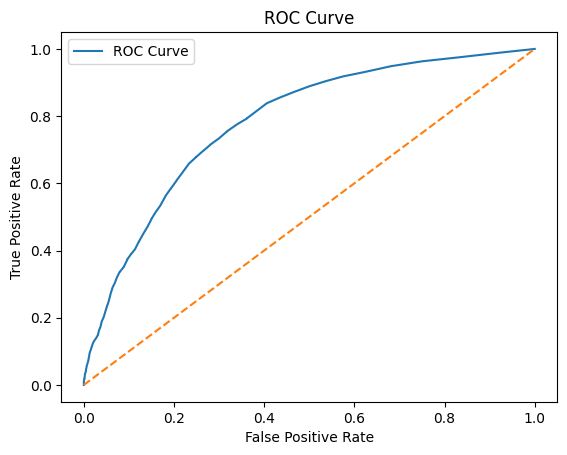

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities
y_prob_2 = model_rf.predict_proba(X_test)[:,1]

# compute ROC
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_prob_2)

# plot ROC
plt.plot(fpr2, tpr2, label="ROC Curve")
plt.plot([0,1],[0,1],'--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("plot11.png")
plt.show()

## Feature Importances

Feature importance for Random Forest as it is the best perofming model 

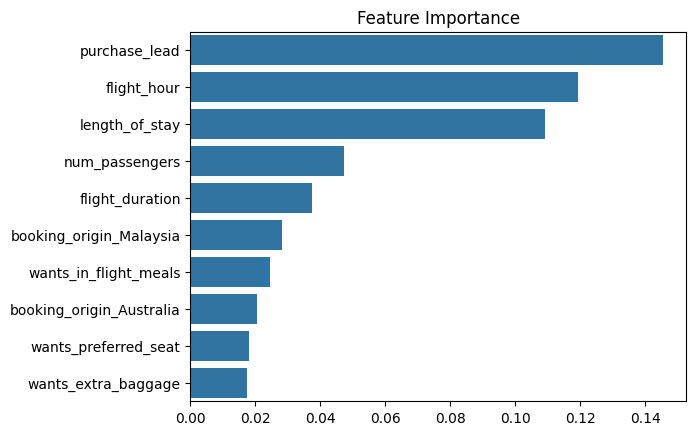

In [46]:
# get feature importance
importances_rf = model_rf.feature_importances_

# convert to datframe
feat_importance_rf = pd.Series(importances_rf, index=X_com_name)

# sort
feat_importance_rf = feat_importance_rf.sort_values(ascending=False).head(10)

# plot
sns.barplot(x=feat_importance_rf.values, y=feat_importance_rf.index)
plt.title("Feature Importance")
plt.ylabel("")
plt.savefig("plot12.png")
plt.show()